In [4]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error

In [6]:
bottle=pd.read_csv('bottle.csv')
cast=pd.read_csv('cast.csv')

C:\Users\jayas\AppData\Local\Temp\ipykernel_22912\52440401.py:1: DtypeWarning: Columns (47,73) have mixed types. Specify dtype option on import or set low_memory=False.
  bottle=pd.read_csv('bottle.csv')
C:\Users\jayas\AppData\Local\Temp\ipykernel_22912\52440401.py:2: DtypeWarning: Columns (40,41,44,45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  cast=pd.read_csv('cast.csv')


In [7]:
bottle.columns

Index(['Cst_Cnt', 'Btl_Cnt', 'Sta_ID', 'Depth_ID', 'Depthm', 'T_degC',
       'Salnty', 'O2ml_L', 'STheta', 'O2Sat', 'Oxy_µmol/Kg', 'BtlNum',
       'RecInd', 'T_prec', 'T_qual', 'S_prec', 'S_qual', 'P_qual', 'O_qual',
       'SThtaq', 'O2Satq', 'ChlorA', 'Chlqua', 'Phaeop', 'Phaqua', 'PO4uM',
       'PO4q', 'SiO3uM', 'SiO3qu', 'NO2uM', 'NO2q', 'NO3uM', 'NO3q', 'NH3uM',
       'NH3q', 'C14As1', 'C14A1p', 'C14A1q', 'C14As2', 'C14A2p', 'C14A2q',
       'DarkAs', 'DarkAp', 'DarkAq', 'MeanAs', 'MeanAp', 'MeanAq', 'IncTim',
       'LightP', 'R_Depth', 'R_TEMP', 'R_POTEMP', 'R_SALINITY', 'R_SIGMA',
       'R_SVA', 'R_DYNHT', 'R_O2', 'R_O2Sat', 'R_SIO3', 'R_PO4', 'R_NO3',
       'R_NO2', 'R_NH4', 'R_CHLA', 'R_PHAEO', 'R_PRES', 'R_SAMP', 'DIC1',
       'DIC2', 'TA1', 'TA2', 'pH2', 'pH1', 'DIC Quality Comment'],
      dtype='object')

In [8]:
cast.columns

Index(['Cst_Cnt', 'Cruise_ID', 'Cruise', 'Cruz_Sta', 'DbSta_ID', 'Cast_ID',
       'Sta_ID', 'Quarter', 'Sta_Code', 'Distance', 'Date', 'Year', 'Month',
       'Julian_Date', 'Julian_Day', 'Time', 'Lat_Dec', 'Lat_Deg', 'Lat_Min',
       'Lat_Hem', 'Lon_Dec', 'Lon_Deg', 'Lon_Min', 'Lon_Hem', 'Rpt_Line',
       'St_Line', 'Ac_Line', 'Rpt_Sta', 'St_Station', 'Ac_Sta', 'Bottom_D',
       'Secchi', 'ForelU', 'Ship_Name', 'Ship_Code', 'Data_Type', 'Order_Occ',
       'Event_Num', 'Cruz_Leg', 'Orig_Sta_ID', 'Data_Or', 'Cruz_Num', 'IntChl',
       'IntC14', 'Inc_Str', 'Inc_End', 'PST_LAN', 'Civil_T', 'TimeZone',
       'Wave_Dir', 'Wave_Ht', 'Wave_Prd', 'Wind_Dir', 'Wind_Spd', 'Barometer',
       'Dry_T', 'Wet_T', 'Wea', 'Cloud_Typ', 'Cloud_Amt', 'Visibility'],
      dtype='object')

In [9]:
cast_small = cast[['Cst_Cnt','Lat_Dec','Lon_Dec']]

In [10]:
df=pd.merge(bottle,cast_small,on='Cst_Cnt', how='inner')

In [11]:

features = ['Depthm', 'Salnty', 'O2ml_L', 'Lat_Dec', 'Lon_Dec']
target = 'T_degC'

In [12]:
df=df[features + [target]]

In [13]:
df.columns


Index(['Depthm', 'Salnty', 'O2ml_L', 'Lat_Dec', 'Lon_Dec', 'T_degC'], dtype='object')

In [14]:
df.shape

(864863, 6)

In [15]:
df.isnull().sum()

Depthm          0
Salnty      47354
O2ml_L     168662
Lat_Dec         0
Lon_Dec         0
T_degC      10963
dtype: int64

In [16]:
df.fillna(df.mean(), inplace=True)

In [17]:
df.isnull().sum()

Depthm     0
Salnty     0
O2ml_L     0
Lat_Dec    0
Lon_Dec    0
T_degC     0
dtype: int64

In [18]:
X=df[features]
y=df[target]

In [19]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [21]:
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred=model.predict(X_test)

In [23]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, y_pred))

Mean Squared Error: 5.0513098529753035
R^2 Score: 0.7152431797109071
Root Mean Squared Error: 2.247511924990678


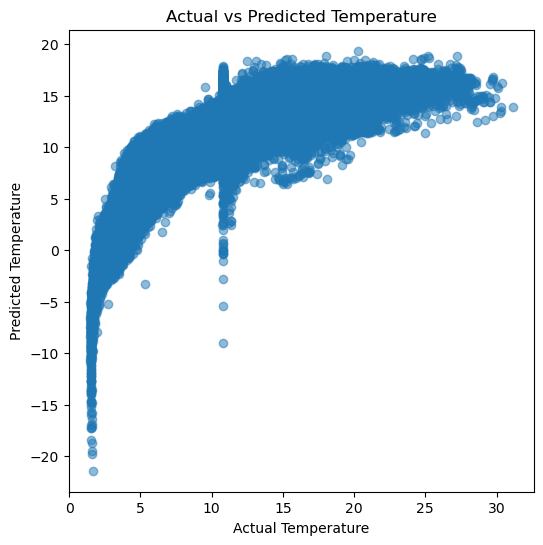

In [24]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()

c:\Users\jayas\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


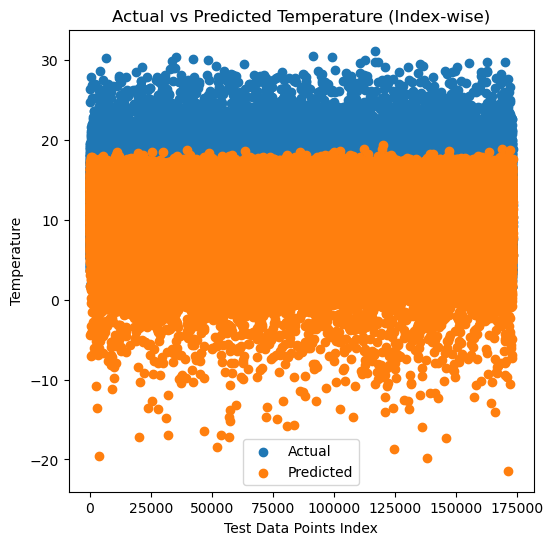

In [25]:
# First get predictions
y_pred = model.predict(X_test)

plt.figure(figsize=(6,6))

# Convert to list (optional but cleaner)
y_test_values = list(y_test)

# Plot Actual values
plt.scatter(range(len(y_test_values)), y_test_values, label="Actual")

# Plot Predicted values
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")

plt.xlabel("Test Data Points Index")
plt.ylabel("Temperature")
plt.title("Actual vs Predicted Temperature (Index-wise)")
plt.legend()

plt.show()

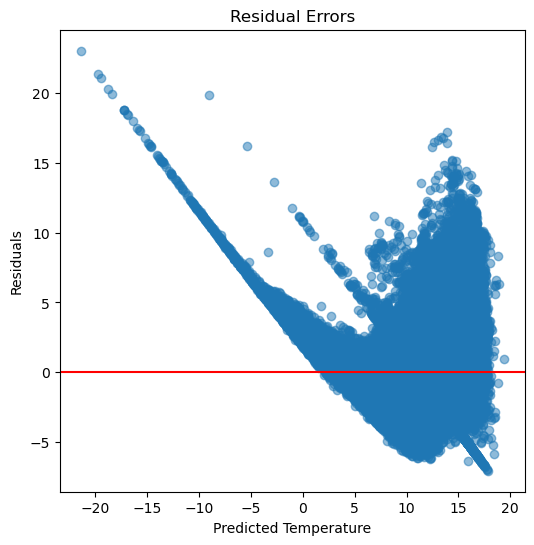

In [26]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(6,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted Temperature")
plt.ylabel("Residuals")
plt.title("Residual Errors")
plt.show()

In [27]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print("\nRidge Regression R2:", r2_score(y_test, ridge_pred))




Ridge Regression R2: 0.7152431791082685


In [28]:
# Lasso Regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("Lasso Regression R2:", r2_score(y_test, lasso_pred))

Lasso Regression R2: 0.7151993441579226
